In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('/content/churn-bigml-80 (1).csv')

In [3]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

# State-Name of the state
#Account length-no.of days customer using the account
#Area code-particular area code
#International plan-does customer having international plan-(yes or no)
#Voice mail plan-Does customer have voice mail plan
#Number vmail messages-how many voice maail does customer get
#Total day minutes-How many minutes does customer used
#Total day call-How many calls does customer get
#Total day charge-how much amount does customer spent on call for total day
#Total eve minutes-how much time does customer spent on evening
#Total eve calls-how much time does customer spent on eve calls
#Total eve charge-how much amount does customer spent on evening
#Total night minutes-how much time does customer spent on night
#Total night calls-how much time does customer spent on night calls
#Total night charge-how much amount does customer charged for a call on night
#Total intl minutes-how many minutes does customer spent on international calls
#Total intl calls-how much time does customer spent on international calls
#Total intl charge--how much amount does customer spent on total intl charge
#Customer srvice calls-How many times customer gets customer service calls
#Churn-customer not using the product



In [5]:
df.shape

(2666, 20)

#In this dataset total 2666 rows and 20 columns are present

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [7]:
#printing the unique values in all the columns
for columns in df.columns:
  print(columns,df[columns].unique)
  print('-'*50)

State <bound method Series.unique of 0       KS
1       OH
2       NJ
3       OH
4       OK
        ..
2661    SC
2662    AZ
2663    WV
2664    RI
2665    TN
Name: State, Length: 2666, dtype: object>
--------------------------------------------------
Account length <bound method Series.unique of 0       128
1       107
2       137
3        84
4        75
       ... 
2661     79
2662    192
2663     68
2664     28
2665     74
Name: Account length, Length: 2666, dtype: int64>
--------------------------------------------------
Area code <bound method Series.unique of 0       415
1       415
2       415
3       408
4       415
       ... 
2661    415
2662    415
2663    415
2664    510
2665    415
Name: Area code, Length: 2666, dtype: int64>
--------------------------------------------------
International plan <bound method Series.unique of 0        No
1        No
2        No
3       Yes
4       Yes
       ... 
2661     No
2662     No
2663     No
2664     No
2665     No
Name: International

In [8]:
for i in df.columns:
  if df[i].dtypes=='object':
     df[i]=df[i].astype('category')

In [9]:
df['State'].dtypes

CategoricalDtype(categories=['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL',
                  'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA',
                  'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE',
                  'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI',
                  'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV',
                  'WY'],
, ordered=False, categories_dtype=object)

In [10]:
df['Churn']=df['Churn'].astype('int')

In [11]:
df.dtypes

,0
State,category
Account length,int64
Area code,int64
International plan,category
Voice mail plan,category
Number vmail messages,int64
Total day minutes,float64
Total day calls,int64
Total day charge,float64
Total eve minutes,float64


In [12]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641,0.145536
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236,0.352707
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000,0.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000,0.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000,0.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   State                   2666 non-null   category
 1   Account length          2666 non-null   int64   
 2   Area code               2666 non-null   int64   
 3   International plan      2666 non-null   category
 4   Voice mail plan         2666 non-null   category
 5   Number vmail messages   2666 non-null   int64   
 6   Total day minutes       2666 non-null   float64 
 7   Total day calls         2666 non-null   int64   
 8   Total day charge        2666 non-null   float64 
 9   Total eve minutes       2666 non-null   float64 
 10  Total eve calls         2666 non-null   int64   
 11  Total eve charge        2666 non-null   float64 
 12  Total night minutes     2666 non-null   float64 
 13  Total night calls       2666 non-null   int64   
 14  Total night charge      

In [14]:
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [15]:
df.duplicated().sum()

0

#NUMERICAL DATA
[Account length,Area code,number vmail messages,total day minutes,total day calls,total day minutes,total day calls,total day charge,total eve calls,total eve minutes,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn]
#CATEGORICAL DATA
[State,international plan,voice mail plan]

In [16]:
import seaborn as sns

<Axes: xlabel='Account length', ylabel='Count'>

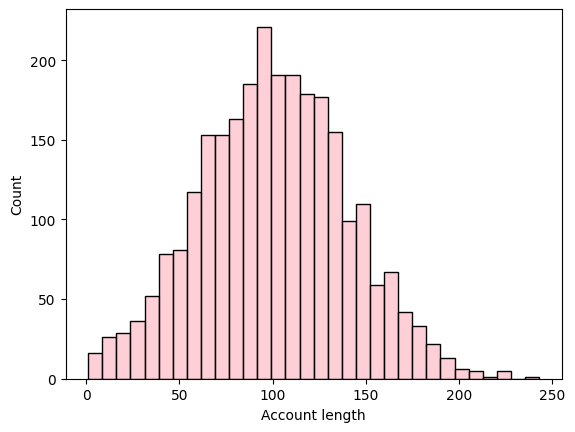

In [17]:
sns.histplot(df['Account length'],color='pink')

In [18]:
df['Area code'].unique()

array([415, 408, 510])

<Axes: xlabel='Area code', ylabel='Count'>

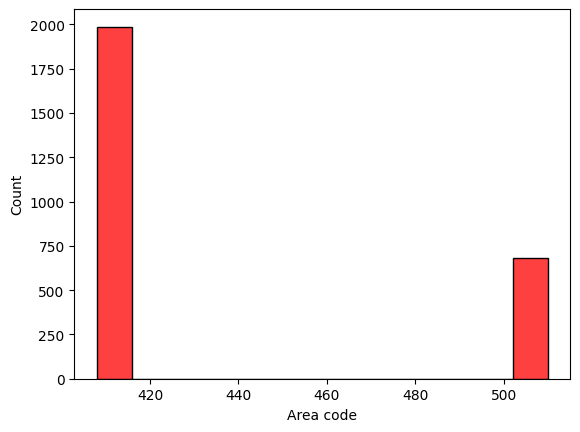

In [19]:
sns.histplot(df['Area code'],color='red')

#we cannot plot the codes with integer data
#we can cosider as categorical data

In [20]:
df['State'].unique()

['KS', 'OH', 'NJ', 'OK', 'AL', ..., 'TN', 'PA', 'HI', 'ND', 'CT']
Length: 51
Categories (51, object): ['AK', 'AL', 'AR', 'AZ', ..., 'WA', 'WI', 'WV', 'WY']

**UNIVARIENT CATEGORICAL PLOTS**

<Axes: xlabel='International plan', ylabel='count'>

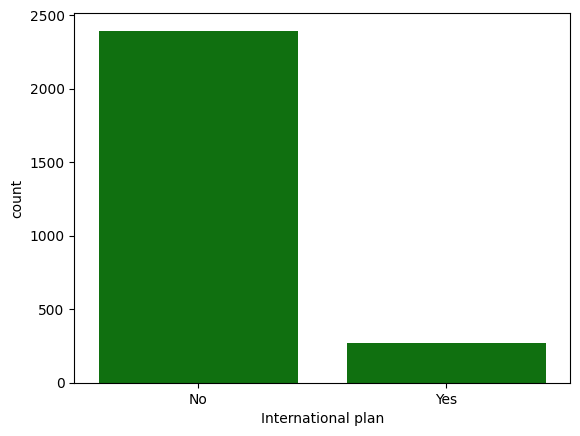

In [21]:
sns.countplot(x=df['International plan'],color='green')

**conclusion**:from this graph we identifies that  there are only 25% of the people having international plan

In [22]:
import matplotlib.pyplot as plt

In [23]:
category_counts=df['Area code'].value_counts()

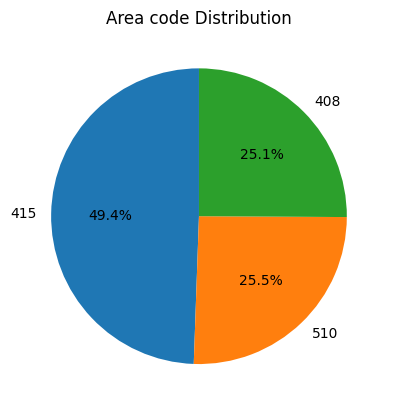

In [24]:
plt.pie(category_counts,labels=category_counts.index,autopct='%1.1f%%',startangle=90)
plt.title('Area code Distribution')
plt.show()

**conclusion**: from this graph we say that the areaa code for each region is different

In [25]:
df['Area code'].value_counts()

,count
Area code,
415,1318
510,679
408,669


**bivarient analysis numerical vs numerical data**

#Account length,Area code,number vmail messages,total day minutes,total day calls,total day minutes,total day calls,total day charge,total eve calls,total eve minutes,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl callstotal intl charge,customer service calls,churn

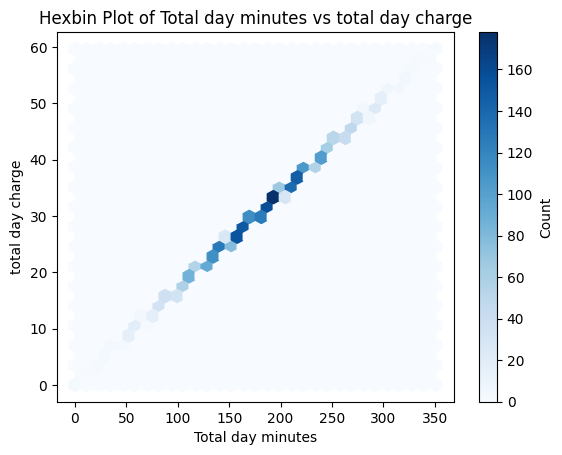

In [26]:
plt.hexbin(df['Total day minutes'], df['Total day charge'], gridsize=30, cmap='Blues')
plt.colorbar(label='Count')
plt.xlabel('Total day minutes')
plt.ylabel('total day charge')
plt.title('Hexbin Plot of Total day minutes vs total day charge')
plt.show()


**conclusion**:from this graph we identify that based on the minutes the person talking on phone charges will get increasing.

<Axes: xlabel='Total day minutes', ylabel='Total day charge'>

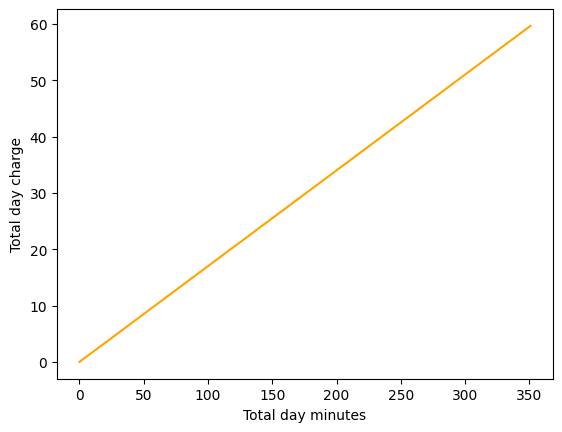

In [27]:
sns.lineplot(x='Total day minutes',y='Total day charge',color='orange',data=df)

**conclusion:**from this graph we conclude that based on the minutes the charges will increasing.

<Axes: xlabel='Total eve calls', ylabel='Total eve charge'>

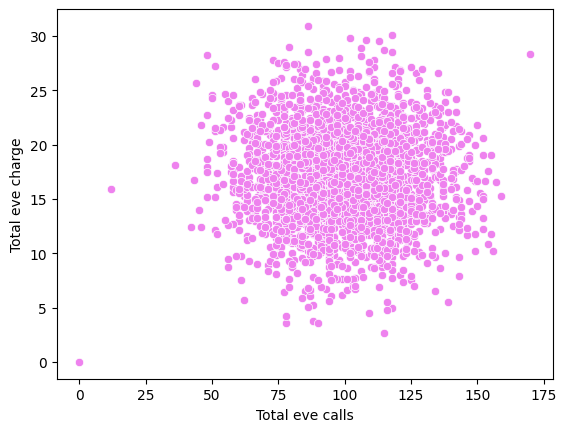

In [28]:
sns.scatterplot(x='Total eve calls',y='Total eve charge',color='violet',data=df)

**conclusion:**from this that graph we conclude that based on the calls that are getting in evening time the charges will be assigned to the customer.

<Axes: xlabel='Total night minutes', ylabel='Total night charge'>

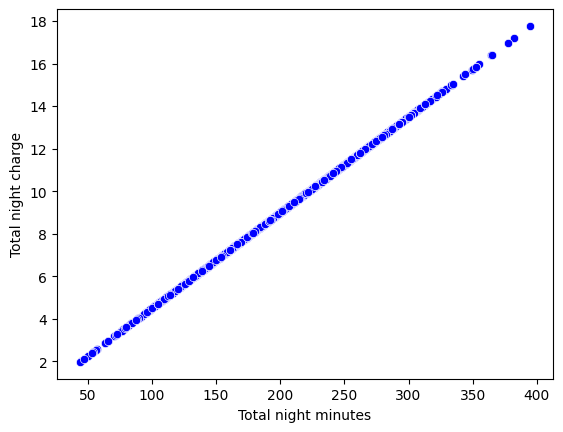

In [29]:
sns.scatterplot(x='Total night minutes',y='Total night charge',color='blue',data=df)

**conclusion:**from this graph we identifies that based on  the total night minutes the charges will be increasing.

<Axes: xlabel='Total intl minutes', ylabel='Total intl charge'>

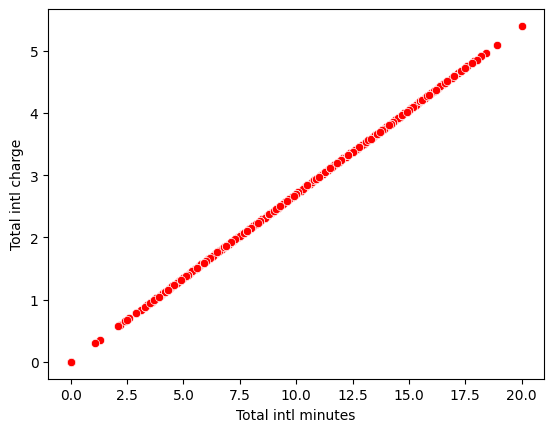

In [30]:
sns.scatterplot(x='Total intl minutes',y='Total intl charge',color='red',data=df)

**conclusion**:from this graph we identifies that based on the total internation minutes the charges will be assigned.

**categorical vs numerical**

<Axes: xlabel='Voice mail plan', ylabel='Total day charge'>

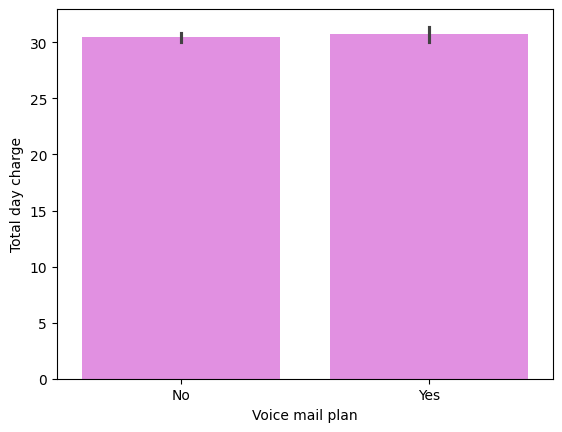

In [31]:
sns.barplot(x='Voice mail plan',y='Total day charge',color='violet',data=df)

**conclusion**:from this graph we conclude that the people who are having or not having the voice mail plan the charges will be the same.

<Axes: xlabel='State', ylabel='Customer service calls'>

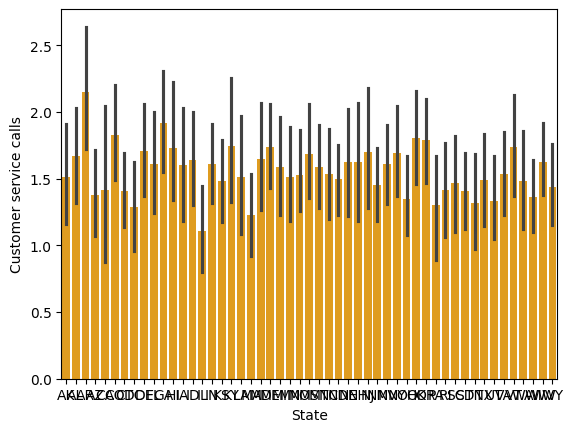

In [32]:
sns.barplot(x='State',y='Customer service calls',color='orange',data=df)

**conclusion**:from this graph we conclude that the people in the AR state will be getting more customer service calls compared with other states.

<Axes: xlabel='International plan', ylabel='Total day charge'>

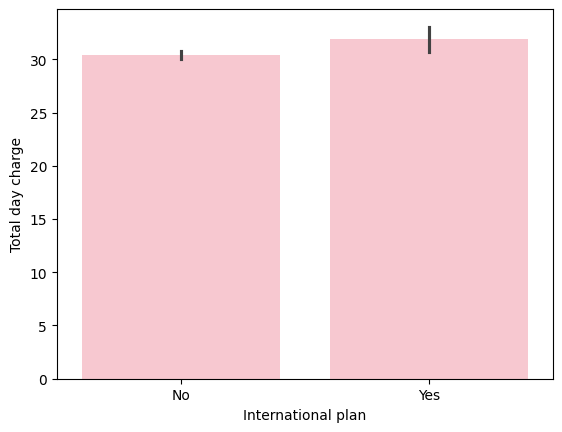

In [33]:
sns.barplot(x='International plan',y='Total day charge',color='pink',data=df)

**conclusion**:from this graph we conclude that the people who are having the international plan will be getting 30% above charges compared with the people not having international plan.

<Axes: xlabel='Voice mail plan', ylabel='Total eve charge'>

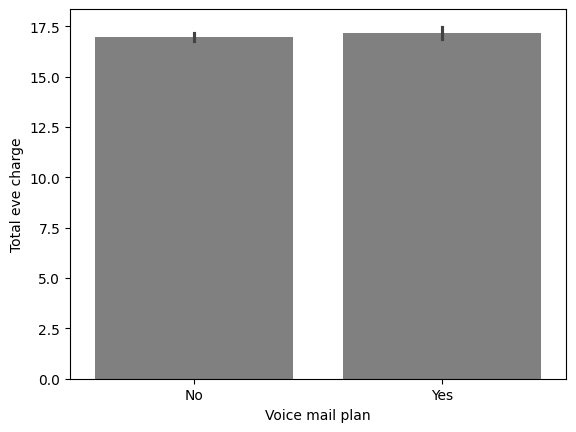

In [34]:
sns.barplot(x='Voice mail plan',y='Total eve charge',color='grey',data=df)

**conclusion**:from this graph we conclude that there is no difference in the evening charges weather the people having voice mail plan or not.

<Axes: xlabel='Voice mail plan', ylabel='Total night charge'>

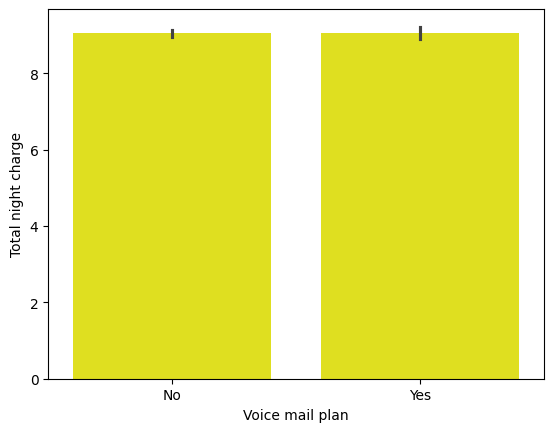

In [35]:
sns.barplot(x='Voice mail plan',y='Total night charge',color='yellow',data=df)

**conclusion**:from this graph we conclude that there is no difference in the night charges weather the people having voice mail plan or not.

**DATA PRE-PROCESSING**

In [36]:
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [37]:
df.drop(['Account length','State','Area code','Customer service calls'],axis=1,inplace=True)

In [38]:
df

,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Churn
0,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,0
1,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,0
2,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,0
4,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,No,No,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,0
2662,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,0
2663,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,0
2664,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,0


**encoding**

In [39]:
size_mapping = {'Yes': 1, 'No': 0}

df['Intl_plan'] = df['International plan'].map(size_mapping)



In [40]:
df.drop('International plan',axis=1,inplace=True)

In [41]:
df

,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Churn,Intl_plan
0,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,0,0
1,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,0,0
2,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,0,1
4,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,No,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,0,0
2662,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,0,0
2663,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,0,0
2664,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,0,0


In [42]:
size_mapping = {'Yes': 1, 'No': 0}

df['Vmail_plan'] = df['Voice mail plan'].map(size_mapping)

In [43]:
df.drop('Voice mail plan',axis=1,inplace=True)

In [44]:
df

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Churn,Intl_plan,Vmail_plan
0,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,0,0,1
1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,0,0,1
2,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,0
3,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,0,1,0
4,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,0,0,0
2662,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,0,0,1
2663,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,0,0,0
2664,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,0,0,0


In [45]:
X = df.iloc[:, df.columns != "Churn"]


In [46]:
X

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Intl_plan,Vmail_plan
0,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,0,1
1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,0,1
2,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,1,0
4,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,0,0
2662,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,0,1
2663,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,0,0
2664,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,0,0


In [47]:
y=df['Churn']

In [48]:
y

,Churn
0,0
1,0
2,0
3,0
4,0
...,...
2661,0
2662,0
2663,0
2664,0


In [49]:
y.shape

(2666,)

In [50]:
df.shape

(2666, 16)

**#Chi-Square Test**

In [51]:
from sklearn.feature_selection import SelectKBest, chi2

In [52]:
chi_selector = SelectKBest(chi2, k=2)
X_selected = chi_selector.fit_transform(X, y)
print("Selected Features:\n", X_selected)

Selected Features:
 [[ 25.  265.1]
 [ 26.  161.6]
 [  0.  243.4]
 ...
 [  0.  231.1]
 [  0.  180.8]
 [ 25.  234.4]]


**Captures non-linear relationships between features and the target.**

In [53]:
from sklearn.feature_selection import mutual_info_classif

In [54]:
mi = mutual_info_classif(X, y)
print("Mutual Information Scores:\n", mi)

Mutual Information Scores:
 [0.00902256 0.0448514  0.         0.04421535 0.         0.
 0.00180493 0.00101791 0.         0.00293801 0.00364001 0.00491728
 0.02077021 0.03050146 0.0221151 ]


#Wrapper methods evaluate subsets of features by training a model and selectingfeatures based on model performance.
**bold text****Recursive Feature Elimination (RFE)**

In [55]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [56]:
model = LogisticRegression()
rfe = RFE(estimator=model, n_features_to_select=2)
X_selected = rfe.fit_transform(X, y)
print("Selected Features:\n", X_selected)
print("Feature Rankings:\n", rfe.ranking_)

Selected Features:
 [[0. 1.]
 [0. 1.]
 [0. 0.]
 ...
 [0. 0.]
 [0. 0.]
 [0. 1.]]
Feature Rankings:
 [ 5  6  7  9 11  8 12 13 10 14  3  2  4  1  1]


In [57]:
from sklearn.model_selection import KFold,cross_val_score

In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()

scores = cross_val_score(model, X, y, cv=kf,scoring='neg_mean_squared_error')
print("K-Fold CV Scores:", scores)
print("Mean MSE:", -np.mean(scores))

K-Fold CV Scores: [-0.13670412 -0.14071295 -0.1575985  -0.12195122 -0.14446529]
Mean MSE: 0.1402864149644089


**train test split**

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify =y)

**Split the training set into training and validation sets**

---



In [61]:
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [63]:
from sklearn.tree import DecisionTreeClassifier


In [64]:
model = DecisionTreeClassifier()


In [65]:
model.fit(X_train_final, y_train_final)


DecisionTreeClassifier()

# Evaluate the model on the validation set

In [66]:
validation_score = model.score(X_val, y_val)
print(f'Validation Accuracy: {validation_score}')


Validation Accuracy: 0.8501170960187353


In [67]:
from sklearn.metrics import accuracy_score

In [69]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9119850187265918


**HYPER_PARAMETR_TUNING**:Grid_search,Random_search

In [70]:
from sklearn.model_selection import GridSearchCV

In [73]:
param_grid = {'max_depth': [3, 5, 7],'criterion': ['gini', 'entropy']}

In [74]:
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best Parameters: {'criterion': 'entropy', 'max_depth': 5}
Best Score: 0.9108885851442458


Finally, after hyperparameter tuning and model selection, evaluate the model on
the test set **bold text**

In [75]:
test_score = model.score(X_test, y_test)
print(f'Test Accuracy: {test_score}')

Test Accuracy: 0.9119850187265918


**scaling the data**

In [76]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df)


In [77]:
normalized_data

array([[0.5       , 0.75570125, 0.6875    , ..., 0.        , 0.        ,
        1.        ],
       [0.52      , 0.46066135, 0.76875   , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.69384265, 0.7125    , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.65877993, 0.35625   , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.51539339, 0.68125   , ..., 0.        , 0.        ,
        0.        ],
       [0.5       , 0.668187  , 0.70625   , ..., 0.        , 0.        ,
        1.        ]])

In [78]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

In [79]:
X_train

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Intl_plan,Vmail_plan
1229,0,271.1,80,46.09,172.0,133,14.62,169.2,105,7.61,10.3,5,2.78,0,0
2001,0,240.2,67,40.83,153.0,98,13.01,249.0,72,11.21,10.2,6,2.75,0,0
1421,0,144.0,90,24.48,135.8,91,11.54,212.4,129,9.56,13.0,4,3.51,0,0
1346,0,169.9,107,28.88,209.4,121,17.80,206.1,79,9.27,11.5,2,3.11,0,0
86,0,238.1,65,40.48,187.2,98,15.91,190.0,115,8.55,11.8,4,3.19,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,0,170.2,98,28.93,155.2,102,13.19,228.6,76,10.29,15.0,2,4.05,0,0
104,27,187.5,124,31.88,146.6,103,12.46,225.7,129,10.16,6.4,6,1.73,0,1
377,34,194.4,63,33.05,254.9,110,21.67,160.2,115,7.21,17.2,9,4.64,0,1
1123,0,200.6,117,34.10,289.5,120,24.61,98.3,95,4.42,11.2,5,3.02,1,0


In [80]:
X_train_scaled

array([[-0.58314258,  1.68838036, -1.00902906, ...,  0.02344267,
        -0.33141911, -0.60770053],
       [-0.58314258,  1.11843214, -1.65545324, ..., -0.01608786,
        -0.33141911, -0.60770053],
       [-0.58314258, -0.65596974, -0.51177969, ...,  0.98535214,
        -0.33141911, -0.60770053],
       ...,
       [ 1.94079099,  0.27365453, -1.85435298, ...,  2.47433529,
        -0.33141911,  1.64554735],
       [-0.58314258,  0.38801307,  0.83079361, ...,  0.33968687,
         3.01732753, -0.60770053],
       [ 1.94079099,  1.63857906,  0.58216893, ...,  0.02344267,
        -0.33141911,  1.64554735]])

**LOGISTIC REGRESSION ALGORITHM**

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm

In [82]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

rf=RandomForestClassifier()
rf.fit(X_train,y_train)

knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

classifier = svm.SVC(kernel='linear')
classifier.fit(X_train,y_train)

SVC(kernel='linear')

In [83]:
y_pred1=lr.predict(X_test)
y_pred2=rf.predict(X_test)
y_pred3=knn.predict(X_test)
y_pred4=dt.predict(X_test)
y_pred5=classifier.predict(X_test)

In [84]:
from sklearn.metrics import accuracy_score

In [85]:
accuracy_score(y_test,y_pred1)


0.8558052434456929

In [86]:
accuracy_score(y_test,y_pred2)


0.9269662921348315

In [87]:
accuracy_score(y_test,y_pred3)


0.8838951310861424

In [88]:
accuracy_score(y_test,y_pred4)


0.8576779026217228

In [89]:
accuracy_score(y_test,y_pred5)


0.8539325842696629

In [90]:
final_data=pd.DataFrame({'Models':['LR','RF','KNN','DT','SVM'],'ACC':[accuracy_score(y_test,y_pred1)*100,
                                              accuracy_score(y_test,y_pred2)*100,
                                               accuracy_score(y_test,y_pred3)*100,
                                             accuracy_score(y_test,y_pred4)*100,
                                                accuracy_score(y_test,y_pred5)*100]})

In [91]:
final_data

,Models,ACC
0,LR,85.580524
1,RF,92.696629
2,KNN,88.389513
3,DT,85.767790
4,SVM,85.393258


<Axes: xlabel='Models', ylabel='ACC'>

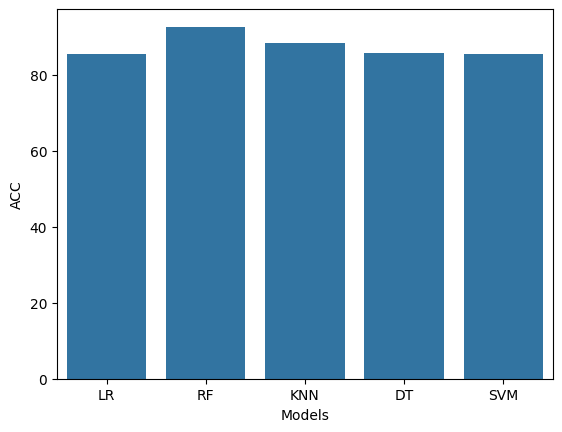

In [92]:
sns.barplot(x=final_data['Models'],y=final_data['ACC'])

save the model

In [93]:
import pickle

In [94]:
with open("DecisionTree.pkl","wb") as file:
    pickle.dump(model,file)

In [95]:
type(X_test)

pandas.core.frame.DataFrame

In [96]:

X_test


,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Intl_plan,Vmail_plan
1396,0,189.3,77,32.18,155.9,128,13.25,186.0,83,8.37,7.4,3,2.00,0,0
542,0,277.5,104,47.18,131.8,121,11.20,126.9,101,5.71,8.2,2,2.21,0,0
2275,0,128.3,78,21.81,215.3,120,18.30,143.7,140,6.47,14.3,9,3.86,0,0
1302,0,222.8,99,37.88,175.8,85,14.94,202.0,111,9.09,11.0,3,2.97,0,0
560,22,175.9,70,29.90,211.7,105,17.99,174.5,81,7.85,7.3,5,1.97,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1728,0,194.3,99,33.03,123.6,133,10.51,229.5,99,10.33,10.2,2,2.75,0,0
51,34,268.6,83,45.66,178.2,142,15.15,166.3,106,7.48,11.6,3,3.13,0,1
1197,14,199.1,100,33.85,221.8,103,18.85,65.7,91,2.96,4.2,1,1.13,0,1
2271,0,183.8,113,31.25,164.7,110,14.00,111.0,87,5.00,10.1,4,2.73,1,0


In [97]:
x={'Number vmail messages':0,'Total day minutes':189.3,'Total day calls':77,'Total day charge':32.18,'Total eve minutes':155.9,'Total eve calls':128,'Total eve charge':13.25,'Total night minutes':186.0,'Total night calls':83,'Total night charge':8.37,'Total intl minutes':7.4,'Total intl calls':3,'Total intl charge':0.0,'Intl_plan':0,'Vmail_plan':1}

In [98]:
x = pd.DataFrame([x])

In [99]:

x

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Intl_plan,Vmail_plan
0,0,189.3,77,32.18,155.9,128,13.25,186.0,83,8.37,7.4,3,0.0,0,1


In [100]:
prediction = model.predict(x)

In [101]:
prediction

array([0])

In [102]:
x={'Number vmail messages':1,'Total day minutes':134.3,'Total day calls':55,'Total day charge':42,'Total eve minutes':126.9,'Total eve calls':132,'Total eve charge':14.56,'Total night minutes':156.0,'Total night calls':78,'Total night charge':8.97,'Total intl minutes':7.4,'Total intl calls':3,'Total intl charge':2.5,'Intl_plan':1,'Vmail_plan':0}

In [103]:
x = pd.DataFrame([x])

In [104]:
x

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Intl_plan,Vmail_plan
0,1,134.3,55,42,126.9,132,14.56,156.0,78,8.97,7.4,3,2.5,1,0


In [105]:
prediction = model.predict(x)

In [106]:
prediction

array([0])